In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
# import matplotlib as mpl
# mpl.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

3 APEC + IB (with no ARF). I fit all (or 5) TM using xSPEC Fit function.

Here I load the data 

In [2]:
AllData.clear()
#path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
path="/home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM1]#,filespectrumTM2,filespectrumTM3,filespectrumTM4,filespectrumTM6,filespectrumTM5,filespectrumTM7]
vfileRMF = [fileRMFTM1]# ,fileRMFTM2,fileRMFTM3,fileRMFTM4,fileRMFTM6,fileRMFTM5,fileRMFTM7]
vfileARF = [fileARFTM1]# ,fileARFTM2,fileARFTM3,fileARFTM4,fileARFTM6,fileARFTM5,fileARFTM7]
#
#LOAD DATA
#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()

#s1 = Spectrum(filespectrumTM1)
#s1.multiresponse[0]=fileRMFTM1
#s1.multiresponse[0].arf=fileARFTM1
#s1.multiresponse[1]=fileRMFTM1 # RMF only for src2


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 3.608e+05 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Ins

Error: cannot read response file srctoolout_120_RMF_00001.fits


In [3]:
######AllData.ignore("**-2.0,,9.0-**")

In [4]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)

for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    #diff = [energiesTMi[i + 1] - energiesTMi[i] for i in range(len(energiesTMi) - 1)]
    #diff = np.array(diff)
    #print(np.min(diff)*1e3," ",np.max(diff)*1e3)
    print("Min max bin width [eV] ",np.min(2*edeltasTMi)*1e3," ",np.max(2*edeltasTMi)*1e3)

Plot command list is now empty
NEbins  1024
Selected values  0.10245336219668388   11.98800277709961  Nbins  1024
Min max bin width [eV]  4.906721413135529   23.99444580078125


Select energy range

In [5]:
#
# Simple check to see that edeltasTMi is half of bin width. energiesTMi is positioned at the center of the bin
#As shown before widths are not constant. NOT linearly spaced bins
#print(energiesTMi)
#print(energiesTMi+2*edeltasTMi)
#
# Also the bins are not log spaced!
#
##logdiff = [np.log(energiesTMi[i + 1] / energiesTMi[i]) for i in range(len(energiesTMi) - 1)]
#logdiff = [np.log(edeltasTMi[i + 1] / edeltasTMi[i]) for i in range(len(edeltasTMi) - 1)]
#logdiff = np.array(logdiff)
#print(len(logdiff))
#print(logdiff)

Check again of bin size directly using RMF file. Same results as before. Ok!

In [6]:
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    #foldedmodel =  np.asarray(Plot.model(plot_grp))
    SpectrumOpen = fits.open(vfilespectrum[i])['SPECTRUM']
    counts = SpectrumOpen.data.field('COUNTS')#
    channel = SpectrumOpen.data.field('CHANNEL')
    exposure=fits.getval(vfilespectrum[i],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[i])['EBOUNDS']
    Emin = RMFOpen.data.field('E_MIN')#keV
    Emax = RMFOpen.data.field('E_MAX')#keV
    Eave = (Emin+Emax)/2.
    DeltaE = Emax-Emin
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    print("ch min and max ",channelmin," ",channelmax)
    DeltaE_ana = DeltaE[channelmin:channelmax]
    Eave_ana = Eave[channelmin:channelmax]
    channel_ana = channel[channelmin:channelmax]
    counts_ana = counts[channelmin:channelmax]
    #Nmodel = foldedmodel*exposure*DeltaE_ana
    print("min counts ",np.min(counts_ana)," ")
    print("max counts ",np.max(counts_ana)," ")
    print("ave counts ",np.mean(counts_ana)," ")
    #print("exposure ",exposure)
    print("DeltaE_ana min and max [eV] ",np.min(DeltaE_ana)*1e3," ",np.max(DeltaE_ana)*1e3)
    print("Eave min and max [keV] ",np.min(Eave_ana)," ",np.max(Eave_ana))
    #print("Folded min/max",np.min(foldedmodel)," ",np.max(foldedmodel))
    print("************")

ch min and max  0   1024
min counts  0  
max counts  2822  
ave counts  387.849609375  
DeltaE_ana min and max [eV]  4.9067216   23.994446
Eave min and max [keV]  0.102453366   11.988003
************


In [7]:
AllData.ignore("**-1.0,,3.0-**")
#AllData.ignore("**-3.0,,4.0-**")

   151 channels (1-151) ignored in spectrum #     1
   646 channels (379-1024) ignored in spectrum #     1



Check the number of counts and energy range

In [8]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts alldata file ",np.min(counts_TMi)," ",np.max(counts_TMi))
    print("Min Max counts analysis ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))
    print("Corresponding to energies ",Eave_ana_TMi[np.argmin(counts_ana_TMi)],Eave_ana_TMi[np.argmax(counts_ana_TMi)])
    print("Emin/Emax all datafile",Emin_data_TMi[0]," ",Emax_data_TMi[-1])


print("In FITS file energy range is [keV] ",Emin_data_TMi[0]," ",Emax_data_TMi[-1])
print("I have 1024 channels ")
deltaE = (Emax_data_TMi[-1]-Emin_data_TMi[0])/1024.
print("Therefore energy bin ",deltaE)
print("eROISTA sigma is between 0.06 and 0.172 keV ")
print("Therefore the bin is below sigma by a factor ",0.06/deltaE," ",0.172/deltaE)

Plot command list is now empty
NEbins  227
***************
Selected values  1.009747564792633   2.986077308654785  Nbins  227
***************
Min Max counts alldata file  0   2822
Min Max counts analysis  214   799
Corresponding to energies  2.3676996 1.0240643
Emin/Emax all datafile 0.1   12.0
In FITS file energy range is [keV]  0.1   12.0
I have 1024 channels 
Therefore energy bin  0.011621093
eROISTA sigma is between 0.06 and 0.172 keV 
Therefore the bin is below sigma by a factor  5.1630254   14.8006735


In [9]:
#print(len(energiesTMi))
#print(len(Eave_ana_TMi))
#print(len(counts_ana_TMi))
#print(len(counts_TMi))
#print(len(Emin_data_TMi))
#print(energiesTMi)
#print(Eave_ana_TMi)
#print(counts_ana_TMi)

I show the size of the energy bins for the energy window I selected. Energy bin size varies! It is not linearly spaced!

In [10]:
#iTM=0
#print(len(venergies[iTM]))
#print(len(vedeltas[iTM]))
#print(np.min(2*vedeltas[iTM])*1e3," ",np.max(2*vedeltas[iTM])*1e3)
#print(np.min(2*vedeltas[3])*1e3," ",np.max(2*vedeltas[3])*1e3)

Min Max counts  214   799


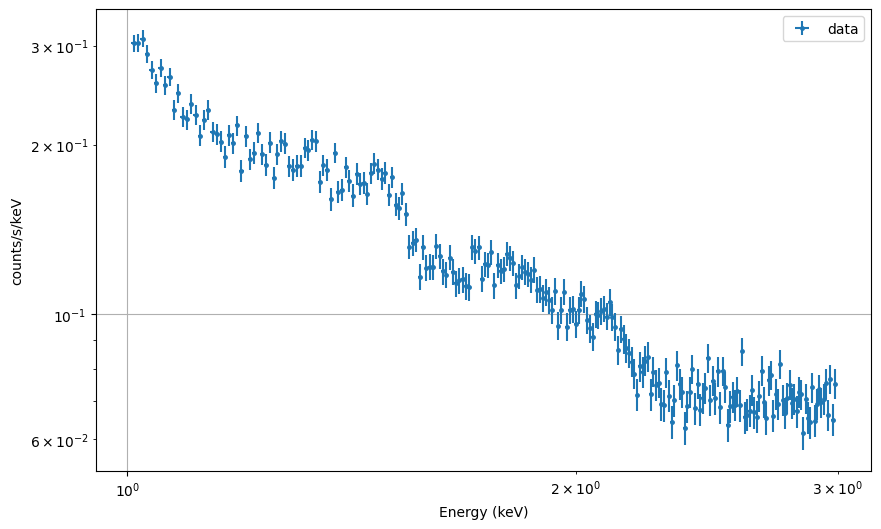

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)): #len(vfilespectrum)
    plot_grp = i + 1 # so that it starts with 1
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

#plt.savefig("Total_RateSpectrum.pdf", format="pdf")

# 16/09/2025
# SAVE in a file with nicer fonts. I do not know it produced PDF properly but it does not show up in the notebook. 
# TO BE FIXED
'''
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
mpl.rcParams['text.latex.preamble'] = r'\usepackage{mathpazo}' #package mathpazo siunitx
plt.rcParams['axes.linewidth'] = 2
plt.rc('text', usetex=True)
plt.rc('font', family='serif') #serif
plt.rcParams['axes.linewidth'] = 2

fig, ax1 = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)): #len(vfilespectrum)
    plot_grp = i + 1 # so that it starts with 1
    ax1.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))

ax1.tick_params(which='major',direction='in',width=1,length=10,top=True,right=True,pad=10)
ax1.tick_params(which='minor',axis='y', direction='in',width=1,length=7,top=True,right=True,pad=10)
ax1.tick_params(which='minor',axis='x', direction='in',width=1,length=7,top=True,right=True,pad=10)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax1.set_xlabel(r'Energy (keV)', size=24)
ax1.set_ylabel(r'counts/s/keV', size=24)
ax1.set_yscale('log')
ax1.set_xscale('log')
#ax1.set_ylim(2e-14,1e-5)
#ax1.set_xlim(1.0,20.)
#plt.legend(fontsize=15)
plt.tight_layout()
plt.savefig('Total_RateSpectrum.pdf',format="pdf")
'''

Define MODEL

In [12]:
Xset.chatter = 1
AllModels.clear()
m_mw = Model("tbabs*(apec+apec+apec+powerlaw)", "mw", 1) 
Xset.restore("/home/jortecal/GitHub/eRosita/TM1_FWC_c010_mod.dat")  # load fwc model from the file
m_fwc = AllModels(1, "fwc")

# First freeze everything in m_fwc
for _name in m_fwc.componentNames:
    #print(_name)
    _comp = m_fwc.__getattribute__(_name)
    for _pname in _comp.parameterNames:
        _par = _comp.__getattribute__(_pname)
        _par.frozen = True

# In m_fwc: for the gaussians free the normalization and, if you want, also their positions (still keep the min,max range)
for _name in m_fwc.componentNames:
    #print(_name)
    if _name == "gaussian" or (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
    #if (_name == "gaussian"):
        _comp = m_fwc.__getattribute__(_name)
        #print(_comp.parameterNames)
        for _pname in _comp.parameterNames:
            #print(_pname)
            if (_pname == "norm") or (_pname == "LineE"):
                _par = _comp.__getattribute__(_pname)
                _par.frozen = False

# In m_fwc: Now free the normalization of the power laws
for _name in m_fwc.componentNames:
    #print(_name)
    if _name == "expfac" or (_name == "bkn2pow") or (_name == "powerlaw") or (_name.startswith("powerlaw") and int(_name.split('_')[-1]) <= 30):
        _comp = m_fwc.__getattribute__(_name)
        #print(_comp.parameterNames)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            _par.frozen = False

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

***Warning: The file sent to Xset.restore(): /home/jortecal/GitHub/eRosita/TM1_FWC_c010_mod.dat
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.




Milkyway halo has a tempreature about 0.2 keV and metallicity less than 0.1 solar.
Local hot bubble has a temperature about 0.1 keV.
Cosmic X-ray background has a photon index of 1.41 (de Luca & Molendi 2004).

In [13]:
m_mw.TBabs.nH = 4.5e-2
# Try to avoid too large values
m_mw.powerlaw.PhoIndex = 1.46 #1.41 
m_mw.powerlaw.PhoIndex.frozen = True #True
m_mw.apec.kT = 0.2
m_mw.apec.kT.frozen = True #True
m_mw.apec.Abundanc = 1.0
m_mw.apec_3.kT = 0.1
m_mw.apec_3.kT.frozen = True #True
m_mw.apec_3.Abundanc = 1.0
m_mw.apec_4.kT = 0.8
m_mw.apec_4.kT.frozen = True #True
m_mw.apec_4.Abundanc = 1.0

In [14]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 2


Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV      9.57069      +/-  0.0          
   3    2   gaussian   Sigma      keV      1.00000E-04  frozen
   4    2   gaussian   norm                1.79509E-03  +/-  0.0          
   5    3   gaussian   LineE      keV      9.10159      +/-  0.0          
   6    3   gaussian   Sigma      keV      1.00000E-04  frozen
   7    3   gaussian   norm                1.69146E-18  +/-  0.0          
   8    4   gaussian   LineE      keV      8.19841      +/-  0.0          
   9    4   gaussian   Sigma      keV      1.00000

In [15]:
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=10000
Fit.perform()
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  290.70212574210774  testStatistics  289.5585871301683  dof  181  nVarPars  46


In [16]:
Fit.perform()
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  290.6691393789341  testStatistics  289.54129998387407  dof  181  nVarPars  46


In [17]:
m_mw.apec.kT.frozen = False
m_mw.apec_3.kT.frozen = False
m_mw.apec_4.kT.frozen = False
m_mw.powerlaw.PhoIndex.frozen = False
Fit.perform()
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  263.4014805971267  testStatistics  262.8598623135024  dof  177  nVarPars  50


In [18]:
Fit.perform()
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  263.381751309283  testStatistics  262.8044291334727  dof  177  nVarPars  50


In [19]:
print("TS/ndf ",Fit.statistic/Fit.dof)
print("p-value ", 1. - chi2_scipy.cdf(Fit.statistic,Fit.dof))
Ndatapoints = len(venergies[0])*len(vfilespectrum)
print("N data points ", Ndatapoints," dof ",Ndatapoints  -Fit.nVarPars)

TS/ndf  1.4880324932727853
p-value  2.6929954825449798e-05
N data points  227  dof  177


In [20]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                  263.38     using 227 bins.

Test statistic : Chi-Squared                  262.80     using 227 bins.
 Null hypothesis probability of 2.98e-05 with 177 degrees of freedom


Plot command list is now empty


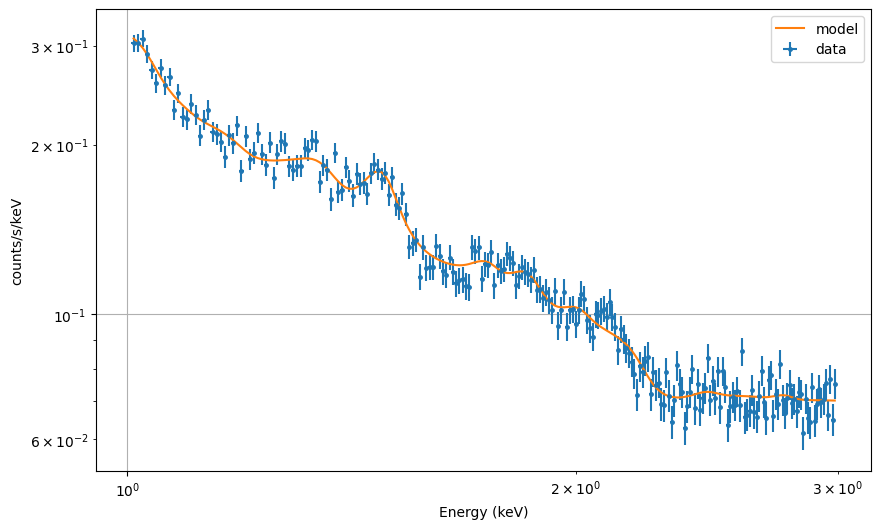

In [21]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

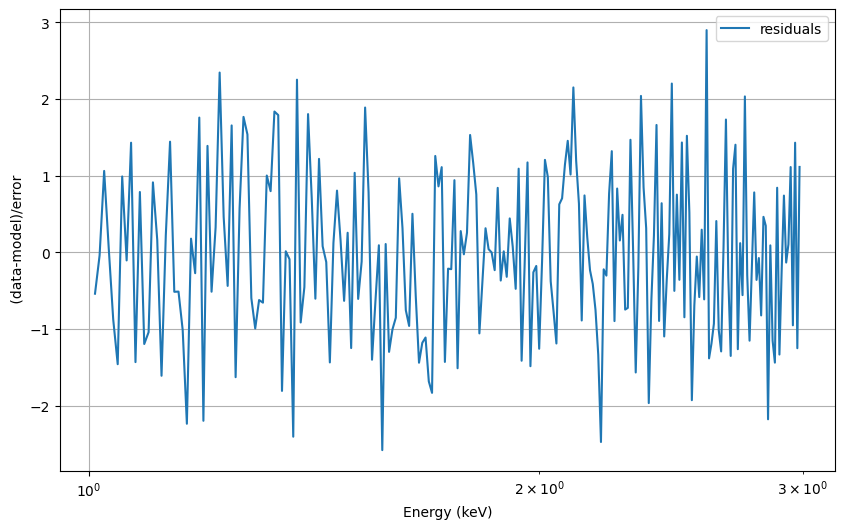

In [22]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  21
0
1
2
3


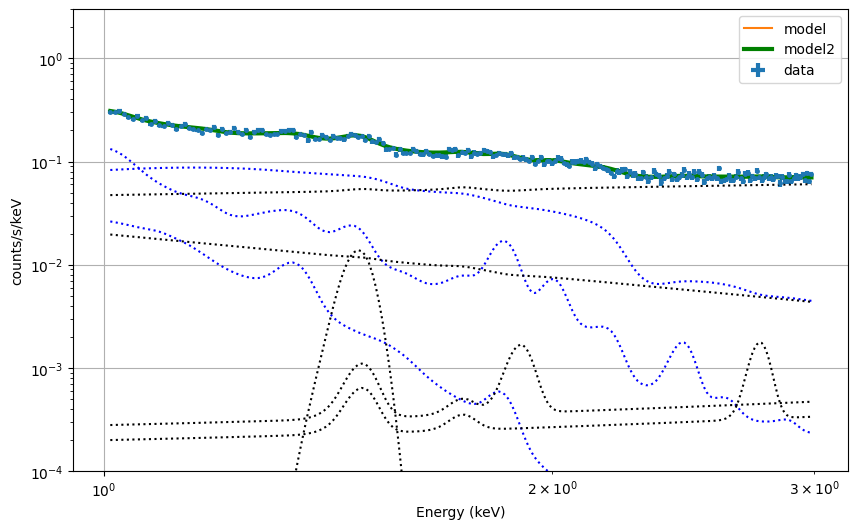

In [23]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model')
ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

for i in range(0,4):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

for i in range(4,nAddComps):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')


ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((0.0001,3.0))
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [24]:
#print(modelcomp[3][:])

In [25]:
m_mw.apec.Abundanc.frozen = False
m_mw.apec_3.Abundanc.frozen = False
m_mw.apec_4.Abundanc.frozen = False

In [26]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 2


Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV      9.70635      +/-  7.67034E+22  
   3    2   gaussian   Sigma      keV      1.00000E-04  frozen
   4    2   gaussian   norm                6.71189E-18  +/-  -1.00000     
   5    3   gaussian   LineE      keV      9.10159      +/-  5.16404E+24  
   6    3   gaussian   Sigma      keV      1.00000E-04  frozen
   7    3   gaussian   norm                2.88363E-19  +/-  -1.00000     
   8    4   gaussian   LineE      keV      8.30159      +/-  -1.00000     
   9    4   gaussian   Sigma      keV      1.00000

In [27]:
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=1000
Fit.perform()
Fit.perform()
Fit.perform()
print("Test Statistics ",Fit.statistic," testStatistics ",Fit.testStatistic," dof ",Fit.dof," nVarPars ",Fit.nVarPars)

Test Statistics  263.35181788236997  testStatistics  262.77708804788716  dof  174  nVarPars  53


In [28]:
print("TS/ndf ",Fit.statistic/Fit.dof)
print("p-value ", 1. - chi2_scipy.cdf(Fit.statistic,Fit.dof))
print("N data points ", Ndatapoints," dof ",Ndatapoints  - Fit.nVarPars)

TS/ndf  1.5135161947262643
p-value  1.4162553618635165e-05
N data points  227  dof  174


In [29]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                  263.35     using 227 bins.

Test statistic : Chi-Squared                  262.78     using 227 bins.
 Null hypothesis probability of 1.57e-05 with 174 degrees of freedom


In [30]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 2


Parameters defined:
Model fwc:constant<1>(gaussian<2> + gaussian<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> + gaussian<9> + gaussian<10> + gaussian<11> + gaussian<12> + gaussian<13> + gaussian<14> + gaussian<15> + expfac<16>(bkn2pow<17> + powerlaw<18> + powerlaw<19>)) Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   constant   factor              1.00000      frozen
   2    2   gaussian   LineE      keV      9.70635      +/-  9.74239E+22  
   3    2   gaussian   Sigma      keV      1.00000E-04  frozen
   4    2   gaussian   norm                6.70881E-18  +/-  -1.00000     
   5    3   gaussian   LineE      keV      9.10159      +/-  5.55990E+24  
   6    3   gaussian   Sigma      keV      1.00000E-04  frozen
   7    3   gaussian   norm                2.88231E-19  +/-  -1.00000     
   8    4   gaussian   LineE      keV      8.30159      +/-  -1.00000     
   9    4   gaussian   Sigma      keV      1.00000

In [31]:
# TM1 
# Test Statistics  882.9099730392908  testStatistics  897.3918676969745  dof  772  nVarPars  53
# Null hypothesis probability of 1.14e-03 with 772 degrees of freedom
# TM2
# Test Statistics  931.1899728287378  testStatistics  947.4281353880231  dof  772  nVarPars  53
# Null hypothesis probability of 1.45e-05 with 772 degrees of freedom
# TM3
# Test Statistics  904.6861624769526  testStatistics  917.636793477566  dof  772  nVarPars  53
#Null hypothesis probability of 2.22e-04 with 772 degrees of freedom

# TM 1,2,3,4,6
# Test Statistics  5613.37429988398  testStatistics  5706.4931075789045  dof  4072  nVarPars  53
# Null hypothesis probability of 6.53e-59 with 4072 degrees of freedom